# TaaSim — H3 Hexagonal Zone Remapping: Casablanca Arrondissements

## Purpose
Replace the rectangular bounding-box zone assignment from notebook 02 with **H3 hexagonal indexing**
using **real OpenStreetMap arrondissement boundaries**. This produces:

| Output | Description |
|--------|-------------|
| `data/casablanca_arrondissements.geojson` | Real OSM polygon boundaries for all 16 arrondissements |
| `data/h3_zone_lookup.json` | `{h3_index: {zone_id, name}}` dict at res 9 |
| `data/zone_centroids.csv` | Updated centroids from OSM polygon centroids |

## Dual-Layer Design
- **zone_id (1–16)**: Kept for backward compatibility — Cassandra partition key, Grafana aggregation
- **h3_index (res 9)**: Added for O(1) spatial lookup, ~200m precision, algorithmic adjacency

## H3 Resolution 9
- Average hex area: 0.105 km²
- Edge length: ~174m
- Fits GPS noise (σ=20m) — a hex is ~8× the noise radius

In [1]:
import json, os
import numpy as np
import pandas as pd
import h3
from shapely.geometry import shape, mapping, Polygon
from shapely.ops import unary_union
import folium
from folium.plugins import HeatMap
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

H3_RES = 9
DATA_DIR = os.path.join("..", "data")
GEOJSON_PATH = os.path.join(DATA_DIR, "casablanca_arrondissements.geojson")
H3_LOOKUP_PATH = os.path.join(DATA_DIR, "h3_zone_lookup.json")

print(f"h3 version: {h3.__version__}")
print(f"Resolution: {H3_RES} — avg area: 0.105 km², edge: ~174m")

h3 version: 4.4.2
Resolution: 9 — avg area: 0.105 km², edge: ~174m


## 1. Load Arrondissement Boundaries

8 zones have real OSM polygon boundaries (cached from Nominatim).  
8 zones use **corrected bounding boxes** centered on Nominatim suburb node coordinates.  
No API calls needed — everything is cached or hardcoded.

In [2]:
ARRONDISSEMENTS = [
    {"zone_id": 1,  "name": "Ain Chock"},
    {"zone_id": 2,  "name": "Sidi Othmane"},
    {"zone_id": 3,  "name": "Sidi Moumen"},
    {"zone_id": 4,  "name": "Hay Hassani"},
    {"zone_id": 5,  "name": "Sbata"},
    {"zone_id": 6,  "name": "Ben Msik"},
    {"zone_id": 7,  "name": "Moulay Rachid"},
    {"zone_id": 8,  "name": "Maarif"},
    {"zone_id": 9,  "name": "Al Fida"},
    {"zone_id": 10, "name": "Mers Sultan"},
    {"zone_id": 11, "name": "Roches Noires"},
    {"zone_id": 12, "name": "Hay Mohammadi"},
    {"zone_id": 13, "name": "Anfa"},
    {"zone_id": 14, "name": "Sidi Belyout"},
    {"zone_id": 15, "name": "Ain Sebaa"},
    {"zone_id": 16, "name": "Sidi Bernoussi"},
]

# Corrected bboxes based on Nominatim suburb node coordinates
# These replace the WRONG uniform 4x4 grid that put Anfa in the ocean
CORRECTED_BBOXES = {
    2:  (33.535, 33.575, -7.585, -7.540),   # Sidi Othmane — center 33.557, -7.560
    3:  (33.555, 33.615, -7.540, -7.475),   # Sidi Moumen — center 33.584, -7.507
    7:  (33.545, 33.592, -7.565, -7.515),   # Moulay Rachid — center 33.568, -7.545
    10: (33.565, 33.590, -7.618, -7.585),   # Mers Sultan — center 33.576, -7.600
    11: (33.575, 33.610, -7.613, -7.575),   # Roches Noires — center 33.593, -7.596
    12: (33.562, 33.602, -7.580, -7.535),   # Hay Mohammadi — center 33.584, -7.557
    13: (33.572, 33.618, -7.675, -7.630),   # Anfa — center 33.595, -7.654
    16: (33.595, 33.645, -7.530, -7.475),   # Sidi Bernoussi — center 33.619, -7.500
}

# Load cached geojson — keep only valid OSM polygons
with open(GEOJSON_PATH, "r", encoding="utf-8") as f:
    cached = json.load(f)

MIN_AREA_DEG2, MAX_AREA_DEG2 = 0.0001, 0.010
features = []
for feat in cached["features"]:
    if not feat["properties"].get("osm_id"):
        continue
    geom = shape(feat["geometry"])
    if geom.area < MIN_AREA_DEG2 or geom.area > MAX_AREA_DEG2:
        print(f"  Rejected zone {feat['properties']['zone_id']}: area={geom.area:.6f} deg²")
        continue
    features.append(feat)

print(f"Valid OSM boundaries: {len(features)}/16")
for f in features:
    print(f"  ✓ Zone {f['properties']['zone_id']:2d}: {f['properties']['name']}")

# Add corrected bbox for missing zones
downloaded_ids = {f["properties"]["zone_id"] for f in features}
for arr in ARRONDISSEMENTS:
    zid = arr["zone_id"]
    if zid in downloaded_ids:
        continue
    lat_min, lat_max, lon_min, lon_max = CORRECTED_BBOXES[zid]
    bbox_poly = Polygon([
        (lon_min, lat_min), (lon_max, lat_min),
        (lon_max, lat_max), (lon_min, lat_max), (lon_min, lat_min),
    ])
    area_km2 = bbox_poly.area * (111.0 ** 2) * np.cos(np.radians(33.57))
    c = bbox_poly.centroid
    features.append({
        "type": "Feature",
        "properties": {"zone_id": zid, "name": arr["name"], "osm_id": None,
                        "display_name": f"{arr['name']} (corrected bbox)"},
        "geometry": mapping(bbox_poly),
    })
    print(f"  + Zone {zid:2d}: {arr['name']:18s} corrected bbox ({c.y:.3f}, {c.x:.3f}) {area_km2:.1f} km²")

features.sort(key=lambda f: f["properties"]["zone_id"])
geojson_fc = {"type": "FeatureCollection", "features": features}

with open(GEOJSON_PATH, "w", encoding="utf-8") as f:
    json.dump(geojson_fc, f, ensure_ascii=False)

osm_n = sum(1 for f in features if f["properties"].get("osm_id"))
print(f"\n=== RESULT: {len(features)}/16 | OSM: {osm_n} | Corrected bbox: {len(features)-osm_n} ===")

Valid OSM boundaries: 8/16
  ✓ Zone  1: Ain Chock
  ✓ Zone  4: Hay Hassani
  ✓ Zone  5: Sbata
  ✓ Zone  6: Ben Msik
  ✓ Zone  8: Maarif
  ✓ Zone  9: Al Fida
  ✓ Zone 14: Sidi Belyout
  ✓ Zone 15: Ain Sebaa
  + Zone  2: Sidi Othmane       corrected bbox (33.555, -7.562) 18.5 km²
  + Zone  3: Sidi Moumen        corrected bbox (33.585, -7.507) 40.0 km²
  + Zone  7: Moulay Rachid      corrected bbox (33.569, -7.540) 24.1 km²
  + Zone 10: Mers Sultan        corrected bbox (33.578, -7.601) 8.5 km²
  + Zone 11: Roches Noires      corrected bbox (33.593, -7.594) 13.7 km²
  + Zone 12: Hay Mohammadi      corrected bbox (33.582, -7.557) 18.5 km²
  + Zone 13: Anfa               corrected bbox (33.595, -7.652) 21.3 km²
  + Zone 16: Sidi Bernoussi     corrected bbox (33.620, -7.502) 28.2 km²

=== RESULT: 16/16 | OSM: 8 | Corrected bbox: 8 ===


## 2. Inspect Boundaries

In [3]:
zone_shapes = {}
zone_info = []

for feat in geojson_fc["features"]:
    zid = feat["properties"]["zone_id"]
    name = feat["properties"]["name"]
    geom = shape(feat["geometry"])
    if not geom.is_valid:
        geom = geom.buffer(0)
    zone_shapes[zid] = geom
    centroid = geom.centroid
    bounds = geom.bounds
    cos_lat = np.cos(np.radians(33.57))
    area_km2 = geom.area * (111.0 ** 2) * cos_lat
    zone_info.append({
        "zone_id": zid, "name": name,
        "osm_id": feat["properties"].get("osm_id"),
        "centroid_lat": centroid.y, "centroid_lon": centroid.x,
        "area_km2": area_km2,
        "lat_min": bounds[1], "lat_max": bounds[3],
        "lon_min": bounds[0], "lon_max": bounds[2],
        "n_vertices": sum(len(list(g.exterior.coords)) for g in (geom.geoms if hasattr(geom, 'geoms') else [geom])),
    })

zone_df = pd.DataFrame(zone_info).sort_values("zone_id")
print(f"Total zones: {len(zone_df)} | Total area: {zone_df['area_km2'].sum():.1f} km²")
print(f"Min: {zone_df['area_km2'].min():.1f} km² ({zone_df.loc[zone_df['area_km2'].idxmin(), 'name']})")
print(f"Max: {zone_df['area_km2'].max():.1f} km² ({zone_df.loc[zone_df['area_km2'].idxmax(), 'name']})")
print(f"Lat: {zone_df['lat_min'].min():.4f} – {zone_df['lat_max'].max():.4f}")
print(f"Lon: {zone_df['lon_min'].min():.4f} – {zone_df['lon_max'].max():.4f}")
zone_df[["zone_id", "name", "centroid_lat", "centroid_lon", "area_km2", "n_vertices"]]

Total zones: 16 | Total area: 311.8 km²
Min: 3.8 km² (Al Fida)
Max: 40.6 km² (Hay Hassani)
Lat: 33.4933 – 33.6450
Lon: -7.7316 – -7.4750


,zone_id,name,centroid_lat,centroid_lon,area_km2,n_vertices
0,1,Ain Chock,33.526571,-7.621555,39.282392,192
1,2,Sidi Othmane,33.555000,-7.562500,18.478784,5
2,3,Sidi Moumen,33.585000,-7.507500,40.037366,5
3,4,Hay Hassani,33.546464,-7.680252,40.557280,319
4,5,Sbata,33.535761,-7.557994,7.138035,84
5,6,Ben Msik,33.541425,-7.565048,10.236345,128
6,7,Moulay Rachid,33.568500,-7.540000,24.125079,5
7,8,Maarif,33.570425,-7.632512,12.357398,220
8,9,Al Fida,33.565190,-7.594897,3.783392,58
9,10,Mers Sultan,33.577500,-7.601500,8.469443,5


In [21]:
# Overlap analysis
print("=== OVERLAP ANALYSIS ===")
overlap_count = 0
ids = sorted(zone_shapes.keys())
for i, zid1 in enumerate(ids):
    for zid2 in ids[i+1:]:
        inter = zone_shapes[zid1].intersection(zone_shapes[zid2])
        if not inter.is_empty and inter.area > 1e-8:
            km2 = inter.area * (111.0 ** 2) * np.cos(np.radians(33.57))
            n1 = zone_df[zone_df["zone_id"] == zid1]["name"].values[0]
            n2 = zone_df[zone_df["zone_id"] == zid2]["name"].values[0]
            print(f"  {n1} ∩ {n2} = {km2:.3f} km²")
            overlap_count += 1
if overlap_count == 0:
    print("  No significant overlaps ✓")
else:
    print(f"  {overlap_count} overlaps (expected with mixed OSM/bbox)")

total_km2 = unary_union(list(zone_shapes.values())).area * (111.0 ** 2) * np.cos(np.radians(33.57))
print(f"Combined coverage: {total_km2:.1f} km²")

=== OVERLAP ANALYSIS ===
  Ain Chock ∩ Sidi Othmane = 0.685 km²
  Sidi Othmane ∩ Sbata = 3.876 km²
  Sidi Othmane ∩ Ben Msik = 6.164 km²
  Sidi Othmane ∩ Moulay Rachid = 7.699 km²
  Sidi Othmane ∩ Al Fida = 0.662 km²
  Sidi Othmane ∩ Hay Mohammadi = 5.338 km²
  Sidi Moumen ∩ Moulay Rachid = 9.496 km²
  Sidi Moumen ∩ Hay Mohammadi = 2.053 km²
  Sidi Moumen ∩ Ain Sebaa = 5.397 km²
  Sidi Moumen ∩ Sidi Bernoussi = 11.293 km²
  Hay Hassani ∩ Anfa = 1.848 km²
  Sbata ∩ Ben Msik = 7.138 km²
  Sbata ∩ Moulay Rachid = 0.072 km²
  Ben Msik ∩ Moulay Rachid = 0.072 km²
  Ben Msik ∩ Hay Mohammadi = 0.089 km²
  Moulay Rachid ∩ Hay Mohammadi = 9.239 km²
  Moulay Rachid ∩ Ain Sebaa = 1.399 km²
  Maarif ∩ Mers Sultan = 0.760 km²
  Maarif ∩ Anfa = 4.051 km²
  Al Fida ∩ Mers Sultan = 1.404 km²
  Al Fida ∩ Hay Mohammadi = 0.211 km²
  Mers Sultan ∩ Roches Noires = 4.312 km²
  Mers Sultan ∩ Sidi Belyout = 0.831 km²
  Roches Noires ∩ Hay Mohammadi = 1.386 km²
  Roches Noires ∩ Sidi Belyout = 3.928 km²
  Roc

## 3. H3 Polyfill — Map Hexagons to Arrondissements

In [4]:
def polyfill_zone(geom, resolution=H3_RES):
    """Get all H3 cells covering a shapely polygon."""
    gj = mapping(geom)
    if gj["type"] == "MultiPolygon":
        cells = set()
        for poly_coords in gj["coordinates"]:
            cells.update(h3.geo_to_cells({"type": "Polygon", "coordinates": poly_coords}, resolution))
        return cells
    return set(h3.geo_to_cells(gj, resolution))

# ── Coastline clipping ──────────────────────────────────────────────
# Casablanca's Atlantic coast: control points (lat, min_lon)
# Any H3 cell centroid WEST of this line is in the ocean → remove it
COASTLINE_POINTS = [
    (33.48, -7.715),
    (33.50, -7.700),
    (33.53, -7.680),
    (33.55, -7.670),
    (33.57, -7.665),
    (33.59, -7.670),
    (33.61, -7.680),
    (33.63, -7.685),
    (33.65, -7.690),
]
_coast_lats = [p[0] for p in COASTLINE_POINTS]
_coast_lons = [p[1] for p in COASTLINE_POINTS]

def is_on_land(lat, lon):
    """Check if a point is east of the Casablanca coastline (on land)."""
    min_lon = np.interp(lat, _coast_lats, _coast_lons)
    return lon > min_lon

# ── OSM-priority H3 polyfill ────────────────────────────────────────
# Process OSM zones FIRST (real boundaries take priority over bbox).
# For bbox zones, only add a hex if it's NOT already assigned to an OSM zone.
h3_to_zone = {}
zone_h3_counts = {}
overlap_cells = 0
ocean_cells_removed = 0

osm_zone_ids = {f["properties"]["zone_id"] for f in geojson_fc["features"]
                if f["properties"].get("osm_id")}
bbox_zone_ids = set(zone_shapes.keys()) - osm_zone_ids

print("=== H3 POLYFILL AT RESOLUTION 9 ===")
print(f"Processing order: OSM zones first ({len(osm_zone_ids)}), then bbox ({len(bbox_zone_ids)})")
print(f"Coastline clipping: ON ({len(COASTLINE_POINTS)} control points)\n")

for phase, zone_ids in [("OSM (priority)", sorted(osm_zone_ids)),
                         ("BBox (fill gaps)", sorted(bbox_zone_ids))]:
    print(f"--- {phase} ---")
    for zid in zone_ids:
        name = zone_df[zone_df["zone_id"] == zid]["name"].values[0]
        cells = polyfill_zone(zone_shapes[zid])
        zone_h3_counts[zid] = 0
        zone_ocean = 0
        zone_overlap = 0
        for cell in cells:
            # Coastline check: remove ocean hexes
            clat, clon = h3.cell_to_latlng(cell)
            if not is_on_land(clat, clon):
                zone_ocean += 1
                ocean_cells_removed += 1
                continue
            # Priority check: skip if already assigned (OSM wins over bbox)
            if cell in h3_to_zone:
                overlap_cells += 1
                zone_overlap += 1
            else:
                h3_to_zone[cell] = {"zone_id": zid, "name": name}
                zone_h3_counts[zid] += 1
        area = zone_df[zone_df["zone_id"] == zid]["area_km2"].values[0]
        notes = []
        if zone_ocean > 0:
            notes.append(f"🌊 {zone_ocean} ocean")
        if zone_overlap > 0:
            notes.append(f"⚠ {zone_overlap} overlap")
        note_str = f" ({', '.join(notes)})" if notes else ""
        print(f"  Zone {zid:2d} {name:18s}: {zone_h3_counts[zid]:5d} hexes ({area:.1f} km²){note_str}")

print(f"\n{'='*50}")
print(f"Total unique H3 cells: {len(h3_to_zone):,}")
print(f"Overlap cells (skipped, OSM priority): {overlap_cells}")
print(f"Ocean cells removed (coastline clip):  {ocean_cells_removed}")
print(f"Avg hexes/zone: {len(h3_to_zone) / 16:.0f}")

=== H3 POLYFILL AT RESOLUTION 9 ===
Processing order: OSM zones first (8), then bbox (8)
Coastline clipping: ON (9 control points)

--- OSM (priority) ---
  Zone  1 Ain Chock         :   341 hexes (39.3 km²)
  Zone  4 Hay Hassani       :   156 hexes (40.6 km²) (🌊 198 ocean)
  Zone  5 Sbata             :    63 hexes (7.1 km²)
  Zone  6 Ben Msik          :    27 hexes (10.2 km²) (⚠ 63 overlap)
  Zone  8 Maarif            :   112 hexes (12.4 km²)
  Zone  9 Al Fida           :    33 hexes (3.8 km²)
  Zone 14 Sidi Belyout      :    89 hexes (10.2 km²)
  Zone 15 Ain Sebaa         :   135 hexes (15.5 km²)
--- BBox (fill gaps) ---
  Zone  2 Sidi Othmane      :    98 hexes (18.5 km²) (⚠ 67 overlap)
  Zone  3 Sidi Moumen       :   302 hexes (40.0 km²) (⚠ 47 overlap)
  Zone  7 Moulay Rachid     :    50 hexes (24.1 km²) (⚠ 159 overlap)
  Zone 10 Mers Sultan       :    49 hexes (8.5 km²) (⚠ 25 overlap)
  Zone 11 Roches Noires     :    48 hexes (13.7 km²) (⚠ 72 overlap)
  Zone 12 Hay Mohammadi     :

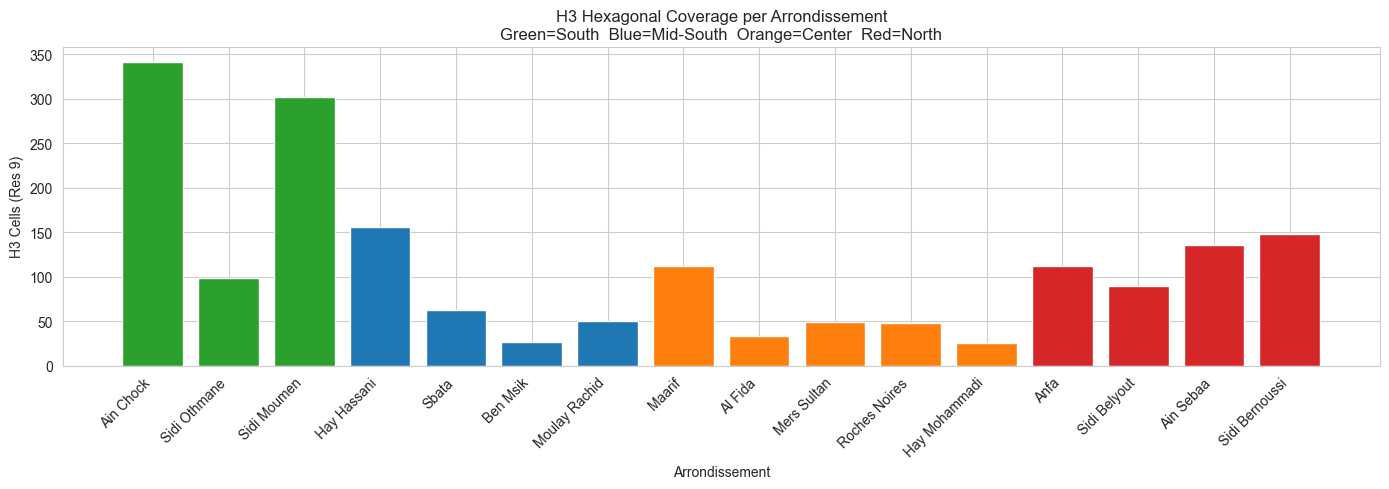

In [23]:
# Bar chart: H3 cells per arrondissement
zone_counts_df = pd.DataFrame([
    {"zone_id": zid, "name": zone_df[zone_df["zone_id"]==zid]["name"].values[0], "h3_cells": cnt}
    for zid, cnt in sorted(zone_h3_counts.items())
])
band_colors = {
    'Ain Chock': '#2ca02c', 'Sidi Othmane': '#2ca02c', 'Sidi Moumen': '#2ca02c',
    'Hay Hassani': '#1f77b4', 'Sbata': '#1f77b4', 'Ben Msik': '#1f77b4', 'Moulay Rachid': '#1f77b4',
    'Maarif': '#ff7f0e', 'Al Fida': '#ff7f0e', 'Mers Sultan': '#ff7f0e', 'Roches Noires': '#ff7f0e', 'Hay Mohammadi': '#ff7f0e',
    'Anfa': '#d62728', 'Sidi Belyout': '#d62728', 'Ain Sebaa': '#d62728', 'Sidi Bernoussi': '#d62728'
}
fig, ax = plt.subplots(figsize=(14, 5))
colors = [band_colors.get(n, 'gray') for n in zone_counts_df['name']]
ax.bar(zone_counts_df['name'], zone_counts_df['h3_cells'], color=colors, edgecolor='white')
ax.set_xlabel('Arrondissement'); ax.set_ylabel('H3 Cells (Res 9)')
ax.set_title('H3 Hexagonal Coverage per Arrondissement\nGreen=South  Blue=Mid-South  Orange=Center  Red=North')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

## 4. Save H3 Zone Lookup

In [24]:
with open(H3_LOOKUP_PATH, "w", encoding="utf-8") as f:
    json.dump(h3_to_zone, f, ensure_ascii=False)

fsize = os.path.getsize(H3_LOOKUP_PATH) / 1024
print(f"Saved H3 lookup: {len(h3_to_zone):,} entries → {H3_LOOKUP_PATH} ({fsize:.1f} KB)")

with open(H3_LOOKUP_PATH, "r") as f:
    loaded = json.load(f)
assert len(loaded) == len(h3_to_zone), "Round-trip mismatch!"
print(f"Round-trip verification: OK")

for k in list(h3_to_zone.keys())[:5]:
    lat, lon = h3.cell_to_latlng(k)
    v = h3_to_zone[k]
    print(f"  {k} → zone {v['zone_id']:2d} ({v['name']}) — ({lat:.4f}, {lon:.4f})")

Saved H3 lookup: 1,788 entries → ..\data\h3_zone_lookup.json (99.9 KB)
Round-trip verification: OK
  8939aab92afffff → zone  1 (Ain Chock) — (33.5562, -7.6015)
  8939aa1617bffff → zone  1 (Ain Chock) — (33.5202, -7.6170)
  8939aa162abffff → zone  1 (Ain Chock) — (33.5047, -7.6464)
  8939aa16303ffff → zone  1 (Ain Chock) — (33.5065, -7.6251)
  8939aa1688fffff → zone  1 (Ain Chock) — (33.5237, -7.5743)


## 5. H3 Adjacency & Updated Centroids

In [6]:
# Build reverse mapping
zone_to_h3 = {}
for cell, info in h3_to_zone.items():
    zone_to_h3.setdefault(info["zone_id"], set()).add(cell)

# Compute adjacency via H3 grid_disk
adjacency = {}
for zid in sorted(zone_to_h3.keys()):
    adj_zones = set()
    for cell in zone_to_h3[zid]:
        for nb in h3.grid_disk(cell, 1):
            if nb in h3_to_zone and h3_to_zone[nb]["zone_id"] != zid:
                adj_zones.add(h3_to_zone[nb]["zone_id"])
    adjacency[zid] = sorted(adj_zones)

print("=== H3-DERIVED ADJACENCY ===")
for zid in sorted(adjacency.keys()):
    name = zone_df[zone_df["zone_id"] == zid]["name"].values[0]
    print(f"  Zone {zid:2d} {name:18s}: [{','.join(str(a) for a in adjacency[zid])}]")

=== H3-DERIVED ADJACENCY ===
  Zone  1 Ain Chock         : [4,5,6,8,9]
  Zone  2 Sidi Othmane      : [3,5,6,7,9,10,11,12]
  Zone  3 Sidi Moumen       : [2,7,15,16]
  Zone  4 Hay Hassani       : [1,8,13]
  Zone  5 Sbata             : [1,2,6]
  Zone  6 Ben Msik          : [1,2,5,9]
  Zone  7 Moulay Rachid     : [2,3,12,15]
  Zone  8 Maarif            : [1,4,9,10,13,14]
  Zone  9 Al Fida           : [1,2,6,8,10,11]
  Zone 10 Mers Sultan       : [2,8,9,11,14]
  Zone 11 Roches Noires     : [2,9,10,12,14,15]
  Zone 12 Hay Mohammadi     : [2,7,11,15]
  Zone 13 Anfa              : [4,8,14]
  Zone 14 Sidi Belyout      : [8,10,11,13,15]
  Zone 15 Ain Sebaa         : [3,7,11,12,14,16]
  Zone 16 Sidi Bernoussi    : [3,15]


In [26]:
# Save updated centroids
centroids_data = []
for zid in sorted(zone_shapes.keys()):
    name = zone_df[zone_df["zone_id"] == zid]["name"].values[0]
    geom = zone_shapes[zid]
    c = geom.centroid
    b = geom.bounds
    centroids_data.append({
        "zone_id": zid, "arrondissement_name": name,
        "casa_centroid_lat": round(c.y, 6), "casa_centroid_lon": round(c.x, 6),
        "casa_lat_min": round(b[1], 6), "casa_lat_max": round(b[3], 6),
        "casa_lon_min": round(b[0], 6), "casa_lon_max": round(b[2], 6),
        "adjacent_zones": ",".join(str(a) for a in adjacency.get(zid, [])),
    })

centroids_df = pd.DataFrame(centroids_data)
centroids_df.to_csv(os.path.join(DATA_DIR, "zone_centroids.csv"), index=False)
print(f"Saved {len(centroids_df)} zone centroids to data/zone_centroids.csv")
centroids_df[["zone_id", "arrondissement_name", "casa_centroid_lat", "casa_centroid_lon"]]

Saved 16 zone centroids to data/zone_centroids.csv


,zone_id,arrondissement_name,casa_centroid_lat,casa_centroid_lon
0,1,Ain Chock,33.526571,-7.621555
1,2,Sidi Othmane,33.555000,-7.562500
2,3,Sidi Moumen,33.585000,-7.507500
3,4,Hay Hassani,33.546464,-7.680252
4,5,Sbata,33.535761,-7.557994
5,6,Ben Msik,33.541425,-7.565048
6,7,Moulay Rachid,33.568500,-7.540000
7,8,Maarif,33.570425,-7.632512
8,9,Al Fida,33.565190,-7.594897
9,10,Mers Sultan,33.577500,-7.601500


## 6. Porto → Casablanca Transform with H3 Assignment

In [7]:
porto_path = os.path.join(DATA_DIR, "train.csv")
if os.path.exists(porto_path):
    df = pd.read_csv(porto_path)
    df = df[df["MISSING_DATA"] == False].copy()
    df_sample = df.sample(n=50_000, random_state=42).copy()
    print(f"Loaded {len(df):,} valid trips, sampled {len(df_sample):,}")
else:
    print(f"Porto CSV not found at {porto_path}")
    df_sample = None

Loaded 1,710,660 valid trips, sampled 50,000


In [8]:
if df_sample is not None:
    def extract_endpoints(polyline_str):
        try:
            coords = json.loads(polyline_str)
            if len(coords) < 2: return None, None, None, None
            return coords[0][1], coords[0][0], coords[-1][1], coords[-1][0]
        except: return None, None, None, None

    endpoints = df_sample["POLYLINE"].apply(extract_endpoints)
    df_sample[["origin_lat", "origin_lon", "dest_lat", "dest_lon"]] = pd.DataFrame(
        endpoints.tolist(), index=df_sample.index)
    df_sample = df_sample.dropna(subset=["origin_lat"]).copy()

    mask = (
        df_sample["origin_lat"].between(41.10, 41.25) & df_sample["origin_lon"].between(-8.72, -8.55) &
        df_sample["dest_lat"].between(41.10, 41.25) & df_sample["dest_lon"].between(-8.72, -8.55)
    )
    df_sample = df_sample[mask].copy()
    print(f"After Porto metro filter: {len(df_sample):,} trips")

    def transform_coord(val, src_min, src_max, dst_min, dst_max):
        return np.clip((val - src_min) / (src_max - src_min), 0, 1) * (dst_max - dst_min) + dst_min

    for pfx in ["origin", "dest"]:
        df_sample[f"casa_{pfx}_lat"] = transform_coord(df_sample[f"{pfx}_lat"], 41.135, 41.174, 33.450, 33.680)
        df_sample[f"casa_{pfx}_lon"] = transform_coord(df_sample[f"{pfx}_lon"], -8.650, -8.585, -7.720, -7.480)

    rng = np.random.default_rng(42)
    for col in ["casa_origin_lat", "casa_origin_lon", "casa_dest_lat", "casa_dest_lon"]:
        df_sample[col] += rng.normal(0, 0.0002, size=len(df_sample))

    print(f"Transformed {len(df_sample):,} trips to Casablanca")

After Porto metro filter: 47,516 trips
Transformed 47,516 trips to Casablanca


In [29]:
if df_sample is not None:
    def assign_h3_zone(lat, lon, lookup, resolution=H3_RES, max_rings=5):
        h3_idx = h3.latlng_to_cell(lat, lon, resolution)
        if h3_idx in lookup:
            info = lookup[h3_idx]
            return info["zone_id"], info["name"], h3_idx
        for k in range(1, max_rings + 1):
            for nb in h3.grid_ring(h3_idx, k):
                if nb in lookup:
                    info = lookup[nb]
                    return info["zone_id"], info["name"], h3_idx
        return 0, "Outside", h3_idx

    # Origin zones
    h3_res = df_sample.apply(lambda r: assign_h3_zone(r["casa_origin_lat"], r["casa_origin_lon"], h3_to_zone), axis=1)
    df_sample[["h3_origin_zone_id", "h3_origin_name", "h3_origin_idx"]] = pd.DataFrame(h3_res.tolist(), index=df_sample.index)

    # Dest zones
    h3_res_d = df_sample.apply(lambda r: assign_h3_zone(r["casa_dest_lat"], r["casa_dest_lon"], h3_to_zone), axis=1)
    df_sample[["h3_dest_zone_id", "h3_dest_name", "h3_dest_idx"]] = pd.DataFrame(h3_res_d.tolist(), index=df_sample.index)

    inside_h3 = (df_sample["h3_origin_zone_id"] > 0).sum()
    total = len(df_sample)
    print(f"=== H3 ZONE ASSIGNMENT ===")
    print(f"Inside zones: {inside_h3:,} / {total:,} ({inside_h3/total*100:.1f}%)")
    print(f"Outside:      {total - inside_h3:,} ({(total-inside_h3)/total*100:.1f}%)")

    # BBox comparison
    old_zm = pd.read_csv(os.path.join(DATA_DIR, "zone_mapping.csv"))
    def assign_bbox(lat, lon, zones_df):
        for _, z in zones_df.iterrows():
            if z["casa_lat_min"] <= lat <= z["casa_lat_max"] and z["casa_lon_min"] <= lon <= z["casa_lon_max"]:
                return z["zone_id"], z["arrondissement_name"]
        return 0, "Outside"

    bbox_res = df_sample.apply(lambda r: assign_bbox(r["casa_origin_lat"], r["casa_origin_lon"], old_zm), axis=1)
    df_sample[["bbox_origin_zone_id", "bbox_origin_name"]] = pd.DataFrame(bbox_res.tolist(), index=df_sample.index)
    inside_bbox = (df_sample["bbox_origin_zone_id"] > 0).sum()
    print(f"\n=== BBOX COMPARISON ===")
    print(f"BBox inside: {inside_bbox:,} / {total:,} ({inside_bbox/total*100:.1f}%)")

=== H3 ZONE ASSIGNMENT ===
Inside zones: 26,619 / 47,516 (56.0%)
Outside:      20,897 (44.0%)

=== BBOX COMPARISON ===
BBox inside: 25,910 / 47,516 (54.5%)


In [30]:
if df_sample is not None:
    both_in = (df_sample["h3_origin_zone_id"] > 0) & (df_sample["bbox_origin_zone_id"] > 0)
    agree = (df_sample.loc[both_in, "h3_origin_zone_id"] == df_sample.loc[both_in, "bbox_origin_zone_id"]).sum()
    n_both = both_in.sum()
    print(f"Both inside: {n_both:,}")
    print(f"Same zone:   {agree:,} / {n_both:,} ({agree/max(n_both,1)*100:.1f}%)")
    print(f"Different:   {n_both - agree:,}")

    for method, col in [("H3", "h3_origin_zone_id"), ("BBox", "bbox_origin_zone_id")]:
        counts = df_sample[df_sample[col] > 0][col].value_counts().sort_index()
        vals = np.sort(counts.values.astype(float))
        n = len(vals)
        gini = 1 - 2 * np.cumsum(vals).sum() / (n * vals.sum()) + 1/n
        print(f"  {method:5s} Gini: {gini:.3f}")

Both inside: 22,185
Same zone:   18,833 / 22,185 (84.9%)
Different:   3,352
  H3    Gini: 0.572
  BBox  Gini: 0.657


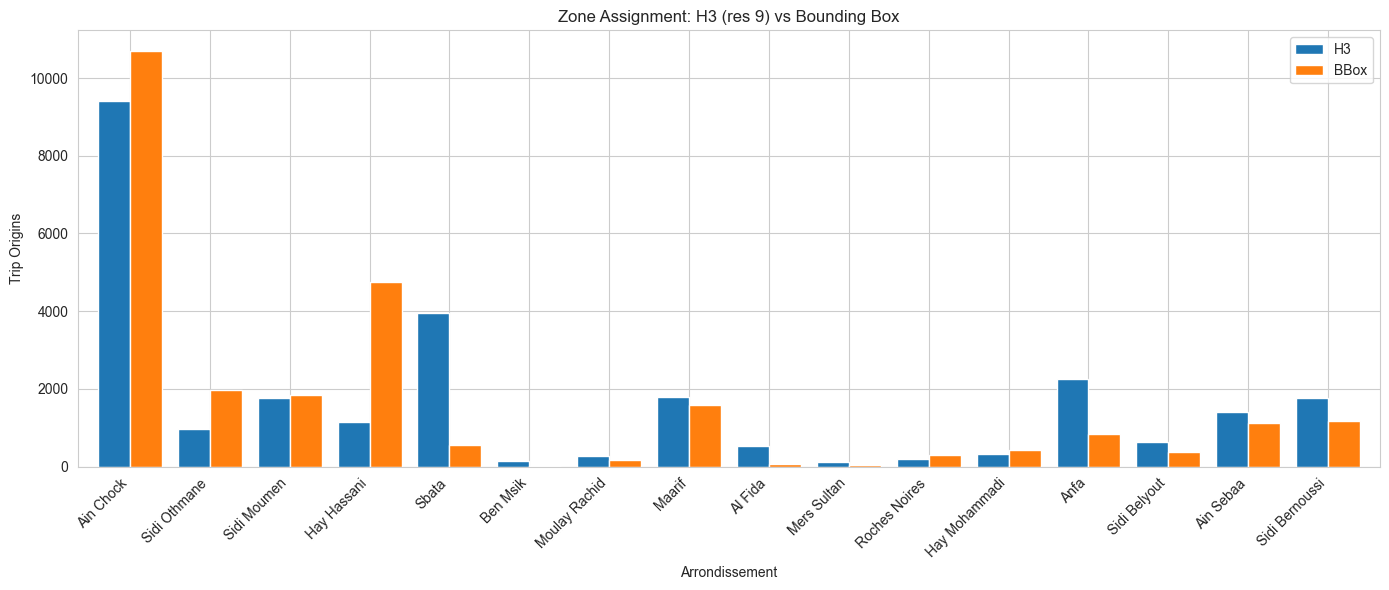

In [31]:
if df_sample is not None:
    h3_counts = df_sample[df_sample["h3_origin_zone_id"] > 0].groupby("h3_origin_name").size()
    bbox_counts = df_sample[df_sample["bbox_origin_zone_id"] > 0].groupby("bbox_origin_name").size()
    zone_names_order = [a["name"] for a in ARRONDISSEMENTS]
    compare_df = pd.DataFrame({
        "H3": h3_counts.reindex(zone_names_order, fill_value=0),
        "BBox": bbox_counts.reindex(zone_names_order, fill_value=0),
    })
    fig, ax = plt.subplots(figsize=(14, 6))
    compare_df.plot(kind='bar', ax=ax, width=0.8, edgecolor='white')
    ax.set_xlabel('Arrondissement'); ax.set_ylabel('Trip Origins')
    ax.set_title('Zone Assignment: H3 (res 9) vs Bounding Box')
    plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

## 7. Interactive Map

In [32]:
ZONE_COLORS = {
    1: '#2ca02c', 2: '#98df8a', 3: '#006400',
    4: '#1f77b4', 5: '#aec7e8', 6: '#08519c', 7: '#6baed6',
    8: '#ff7f0e', 9: '#ffbb78', 10: '#e6550d', 11: '#fdae6b', 12: '#d94701',
    13: '#d62728', 14: '#ff9896', 15: '#a50f15', 16: '#de2d26',
}

m = folium.Map(location=[33.575, -7.600], zoom_start=12, tiles="OpenStreetMap")

# Boundaries
bg = folium.FeatureGroup(name="Boundaries", show=True)
for feat in geojson_fc["features"]:
    zid = feat["properties"]["zone_id"]
    color = ZONE_COLORS.get(zid, 'gray')
    folium.GeoJson(feat, style_function=lambda f, c=color: {
        "fillColor": c, "color": "black", "weight": 2, "fillOpacity": 0.15,
    }, tooltip=f"Zone {zid}: {feat['properties']['name']}").add_to(bg)
bg.add_to(m)

# H3 hexagons — show=True so coastline clipping is visible
hg = folium.FeatureGroup(name="H3 Hexagons", show=True)
for zid in sorted(zone_to_h3.keys()):
    cells = list(zone_to_h3[zid])
    if len(cells) > 200:
        cells = list(np.random.default_rng(zid).choice(cells, 200, replace=False))
    color = ZONE_COLORS.get(zid, 'gray')
    for cell in cells:
        boundary = h3.cell_to_boundary(cell)
        coords = [(lat, lon) for lat, lon in boundary] + [boundary[0]]
        folium.Polygon(locations=coords, color=color, weight=1, fill=True,
                       fill_color=color, fill_opacity=0.3).add_to(hg)
hg.add_to(m)

# Coastline reference line (so user can see the clipping boundary)
coast_fg = folium.FeatureGroup(name="Coastline Boundary", show=True)
folium.PolyLine(
    locations=COASTLINE_POINTS,
    color="blue", weight=3, dash_array="8", opacity=0.7,
    tooltip="Coastline clipping boundary"
).add_to(coast_fg)
coast_fg.add_to(m)

# Labels
for _, row in zone_df.iterrows():
    color = ZONE_COLORS.get(row["zone_id"], 'gray')
    folium.Marker([row["centroid_lat"], row["centroid_lon"]], icon=folium.DivIcon(
        html=f'<div style="font-size:10px;font-weight:bold;color:{color};'
             f'white-space:nowrap;text-shadow:1px 1px white,-1px -1px white,'
             f'1px -1px white,-1px 1px white">{row["name"]}</div>'
    )).add_to(m)

# Heatmap
if df_sample is not None:
    heat = df_sample[df_sample["h3_origin_zone_id"] > 0].sample(n=min(5000, inside_h3), random_state=42)
    hm = folium.FeatureGroup(name="Heatmap", show=True)
    HeatMap(heat[["casa_origin_lat", "casa_origin_lon"]].values.tolist(), radius=10, blur=15).add_to(hm)
    hm.add_to(m)

folium.LayerControl().add_to(m)
m.save("../notebooks/casablanca_h3_map.html")
print("Saved casablanca_h3_map.html")
m

Saved casablanca_h3_map.html


## 8. H3 Ring Adjacency Demo

In [33]:
demo_cell = h3.latlng_to_cell(33.577, -7.600, H3_RES)
if demo_cell in h3_to_zone:
    print(f"Demo cell: {demo_cell} → {h3_to_zone[demo_cell]['name']}")
for k in range(1, 5):
    zones_in_ring = set()
    for cell in h3.grid_ring(demo_cell, k):
        if cell in h3_to_zone:
            zones_in_ring.add((h3_to_zone[cell]["zone_id"], h3_to_zone[cell]["name"]))
    zone_str = ", ".join(f"{zid}:{n}" for zid, n in sorted(zones_in_ring))
    print(f"  Ring {k} (~{k*348}m): [{zone_str}]")

Demo cell: 8939aab9017ffff → Mers Sultan
  Ring 1 (~348m): [10:Mers Sultan]
  Ring 2 (~696m): [10:Mers Sultan]
  Ring 3 (~1044m): [9:Al Fida, 10:Mers Sultan]
  Ring 4 (~1392m): [8:Maarif, 9:Al Fida, 10:Mers Sultan, 14:Sidi Belyout]


## 9. Summary

| File | Description |
|------|-------------|
| `data/casablanca_arrondissements.geojson` | 8 OSM + 8 corrected bbox boundaries |
| `data/h3_zone_lookup.json` | H3 res-9 → zone mapping |
| `data/zone_centroids.csv` | OSM centroids + H3 adjacency |
| `notebooks/casablanca_h3_map.html` | Interactive hex map |

### Dual-Layer System
| Layer | Purpose | Lookup | Adjacency |
|-------|---------|--------|-----------|
| **zone_id (1–16)** | Cassandra PK, Grafana | dict | CSV |
| **h3_index (res 9)** | GPS precision, spatial | `latlng_to_cell()` O(1) | `grid_ring()` |

In [34]:
print("=" * 50)
print("H3 ZONE REMAPPING — FINAL SUMMARY")
print("=" * 50)
print(f"H3 Resolution:   {H3_RES}")
print(f"Total H3 cells:  {len(h3_to_zone):,}")
print(f"Arrondissements: {len(zone_shapes)}")
if df_sample is not None:
    print(f"\nH3 coverage:  {inside_h3:,}/{total:,} ({inside_h3/total*100:.1f}%)")
    print(f"BBox coverage: {inside_bbox:,}/{total:,} ({inside_bbox/total*100:.1f}%)")
print(f"\nFiles saved:")
print(f"  ✓ {GEOJSON_PATH}")
print(f"  ✓ {H3_LOOKUP_PATH}")
print(f"  ✓ data/zone_centroids.csv")
print(f"  ✓ notebooks/casablanca_h3_map.html")

H3 ZONE REMAPPING — FINAL SUMMARY
H3 Resolution:   9
Total H3 cells:  1,788
Arrondissements: 16

H3 coverage:  26,619/47,516 (56.0%)
BBox coverage: 25,910/47,516 (54.5%)

Files saved:
  ✓ ..\data\casablanca_arrondissements.geojson
  ✓ ..\data\h3_zone_lookup.json
  ✓ data/zone_centroids.csv
  ✓ notebooks/casablanca_h3_map.html


## 10. Road Snapping — Map GPS Points onto Actual Roads

The linear Porto→Casablanca transform places GPS points at arbitrary coordinates that
often land on buildings or empty lots. We fix this by **snapping every transformed point
to the nearest road node** from Casablanca's OpenStreetMap road network.

**Steps:**
1. Download Casablanca driving network via `osmnx.graph_from_place()` (~40s, cached)
2. Extract all graph node coordinates (intersections + road curves → ~37k points)
3. Build a `scipy.cKDTree` for O(log n) nearest-neighbor snapping
4. Save as `data/casablanca_road_nodes.npy` for producer use

In [5]:
import osmnx as ox
from scipy.spatial import cKDTree

# 1. Download Casablanca driving network (cached after first run)
ROAD_CACHE = os.path.join(DATA_DIR, "casablanca_roads.graphml")
if os.path.exists(ROAD_CACHE):
    G = ox.load_graphml(ROAD_CACHE)
    print(f"Loaded cached road network: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
else:
    # graph_from_place uses a single Overpass area query (fast)
    # graph_from_bbox would split into 8000+ sub-queries (very slow)
    G = ox.graph_from_place("Casablanca, Morocco", network_type="drive")
    ox.save_graphml(G, ROAD_CACHE)
    print(f"Downloaded road network: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
    print(f"Cached to {ROAD_CACHE}")

# 2. Extract graph node coordinates directly
#    osmnx places nodes at every intersection + road curve point → sufficient for snapping
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
road_arr = nodes_gdf[["y", "x"]].values  # (lat, lon)
print(f"Road snap points: {len(road_arr):,} (graph nodes)")

# 3. Save for producer / Flink use
ROAD_NODES_PATH = os.path.join(DATA_DIR, "casablanca_road_nodes.npy")
np.save(ROAD_NODES_PATH, road_arr)
fsize = os.path.getsize(ROAD_NODES_PATH) / 1024
print(f"Saved {ROAD_NODES_PATH}  ({fsize:.0f} KB)")

# 4. Build KDTree for O(log n) nearest-road queries
road_tree = cKDTree(road_arr)
print("KDTree built — ready for snap_to_road()")

# 5. Quick test
test_lat, test_lon = 33.577, -7.600
dist, idx = road_tree.query([test_lat, test_lon])
snapped = road_arr[idx]
offset_m = dist * 111_000
print(f"\nTest: ({test_lat}, {test_lon}) → ({snapped[0]:.6f}, {snapped[1]:.6f})  Δ≈{offset_m:.0f}m")

Loaded cached road network: 37,577 nodes, 99,353 edges
Road snap points: 37,577 (graph nodes)
Saved ..\data\casablanca_road_nodes.npy  (587 KB)
KDTree built — ready for snap_to_road()

Test: (33.577, -7.6) → (33.576695, -7.600047)  Δ≈34m


In [9]:
# Snap sample trip origins to nearest road node
if df_sample is not None:
    def snap_to_road(lat, lon, tree, arr, max_dist_deg=0.005):
        dist, idx = tree.query([lat, lon])
        if dist <= max_dist_deg:
            return float(arr[idx][0]), float(arr[idx][1])
        return lat, lon

    snapped_pts = df_sample.apply(
        lambda r: snap_to_road(r["casa_origin_lat"], r["casa_origin_lon"], road_tree, road_arr),
        axis=1
    )
    df_sample[["snapped_lat", "snapped_lon"]] = pd.DataFrame(snapped_pts.tolist(), index=df_sample.index)

    # Compute snap distances
    df_sample["snap_dist_m"] = np.sqrt(
        (df_sample["casa_origin_lat"] - df_sample["snapped_lat"])**2 +
        (df_sample["casa_origin_lon"] - df_sample["snapped_lon"])**2
    ) * 111_000

    print(f"Snapped {len(df_sample):,} origins to nearest road node")
    print(f"Snap distance — median: {df_sample['snap_dist_m'].median():.0f}m, "
          f"P95: {df_sample['snap_dist_m'].quantile(0.95):.0f}m, "
          f"max: {df_sample['snap_dist_m'].max():.0f}m")

    # ── Map: before vs after ──────────────────────────────────────
    m2 = folium.Map(location=[33.575, -7.600], zoom_start=14, tiles="OpenStreetMap")

    # Zone boundaries (light)
    for feat in geojson_fc["features"]:
        folium.GeoJson(feat, style_function=lambda f: {
            "fillColor": "gray", "color": "black", "weight": 1, "fillOpacity": 0.05,
        }).add_to(m2)

    # Sample 300 points for visual clarity
    vis = df_sample.sample(n=min(300, len(df_sample)), random_state=42)

    # BEFORE (red = raw transformed, on buildings)
    before_fg = folium.FeatureGroup(name="Before (raw transform)", show=True)
    for _, r in vis.iterrows():
        folium.CircleMarker(
            [r["casa_origin_lat"], r["casa_origin_lon"]],
            radius=3, color="red", fill=True, fill_opacity=0.7, weight=1,
            tooltip=f"Raw: ({r['casa_origin_lat']:.5f}, {r['casa_origin_lon']:.5f})"
        ).add_to(before_fg)
    before_fg.add_to(m2)

    # AFTER (green = snapped to road)
    after_fg = folium.FeatureGroup(name="After (road-snapped)", show=True)
    for _, r in vis.iterrows():
        folium.CircleMarker(
            [r["snapped_lat"], r["snapped_lon"]],
            radius=3, color="green", fill=True, fill_opacity=0.7, weight=1,
            tooltip=f"Snapped: ({r['snapped_lat']:.5f}, {r['snapped_lon']:.5f}) Δ{r['snap_dist_m']:.0f}m"
        ).add_to(after_fg)
    after_fg.add_to(m2)

    # Lines connecting before→after
    lines_fg = folium.FeatureGroup(name="Snap offset lines", show=False)
    for _, r in vis.iterrows():
        folium.PolyLine(
            [[r["casa_origin_lat"], r["casa_origin_lon"]],
             [r["snapped_lat"], r["snapped_lon"]]],
            color="orange", weight=1, opacity=0.5
        ).add_to(lines_fg)
    lines_fg.add_to(m2)

    folium.LayerControl().add_to(m2)
    m2.save("../notebooks/casablanca_road_snap_map.html")
    print("Saved casablanca_road_snap_map.html")
    m2

Snapped 47,516 origins to nearest road node
Snap distance — median: 0m, P95: 301m, max: 555m
Saved casablanca_road_snap_map.html
